# Evaluation Plots

Vision: 

```
from ocean_emulators.plotting import eval_plots

training_url = ...
prediction_url = ...

eval_plots(training_url, prediction_url)
```

Where

```
def eval_plots(...):
    # Run tests on prediction data
    # Plot all relevant panels in a neat and organized way
```


### Imports

In [105]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
from xarrayutils.plotting import linear_piecewise_scale
from dask.diagnostics import ProgressBar

### Utils

In [106]:
import sys
sys.path.append("../ocean_emulators_main/")

from ocean_emulators.dataset_validation import ds_input_validate, ds_prediction_validate
from ocean_emulators.postprocessing import post_processor

### Data

In [107]:

def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here
    try:
        ds_input_validate(ds_truth, deep=False)
    except ValueError as e:
        raise ValueError(
            f"Checking the input dataset failed with {e}. Please fix those issues before creating a postprocessed dataset."
        )

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})
        warnings.warn(
            "Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream"
        )

    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out


In [108]:
import os
import pandas as pd

levels = 19
emulation_stability=False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()

ds_input_validate(ds_input)

# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_groundtruth = ds_input.isel(time=slice(4143, 4743)).isel(lev=slice(None, levels))


ls = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
Pred_path = "/pscratch/sd/s/suryad/Ocean_Emulator/Preds/2024-09-04_ConvNextUNetTrain3Dv021Eval3DCosLossEpochs70Epoch19_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr"
output_folder = Pred_path.split("/")[-2].split("_Train")[0]
output_path = os.path.join("./temp", output_folder)

if os.path.isdir(output_path):
    print("Using Output Folder : ", output_path)
else:
    print("Using Output Folder : ../outputs")
    output_path = "../outputs"

ds_prediction_raw = xr.open_zarr(Pred_path)

# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction = post_processor(
    ds_prediction_raw, ds_groundtruth, ls
)

# Run the test to make sure the output is formatted correctly
ds_prediction_validate(ds_prediction)

Using Output Folder :  ./temp/2024-09-04_ConvNextUNetTrain3Dv021Eval3DCosLossEpochs70Epoch19


/tmp/ipykernel_1984116/4147618335.py:14: UserWarning: Swapped x and y dimensions detected. Fixing this now, but should be corrected upstream
  warnings.warn(
/pscratch/sd/s/suryad/Ocean_Emulator/notebooks/../ocean_emulators_main/ocean_emulators/dataset_validation.py:51: UserWarning: This checks nothing yet
  warnings.warn("This checks nothing yet")


### Depth Profiles

In [109]:
def profile_mean(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(["x", "y"])

def profile_std(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).std(["x", "y"])

def full_std(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello*ds.dz).std(["x", "y","lev"]).mean("time")

In [110]:
with ProgressBar():
    if 'uo' in ls:
        print("KE generating...")
        ds_groundtruth = ds_groundtruth.assign(KE=0.5 * (ds_groundtruth.uo ** 2 + ds_groundtruth.vo ** 2)*1020)
        ds_prediction = ds_prediction.assign(KE=0.5 * (ds_prediction.uo ** 2 + ds_prediction.vo ** 2)*1020)
        ls.append('KE')
    profile_prediction = profile_mean(ds_prediction).load()
    profile_groundtruth = profile_mean(ds_groundtruth).load()
    # profile_stdv_prediction = profile_std(ds_prediction).load()
    # profile_stdv_groundtruth = profile_std(ds_groundtruth).load()
    stdv_groundtruth = full_std(ds_groundtruth).load()

KE generating...
[########################################] | 100% Completed | 29.18 s
[########################################] | 100% Completed | 32.48 s
[########################################] | 100% Completed | 58.56 s


In [111]:
def adjust_depth(ax):
    # todo make split vertical axes
    linear_piecewise_scale(1000, 5, ax=ax)
    # indicate the point between the different scalings
    ax.axhline(1000, color="0.5", ls="--")
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
    
var_list = {
        "vo": r"$v$ $( m/s )$",
        "uo": r"$u$ $( m/s )$",
        "thetao": r"$T$ $( ^\circ C )$",
        "so": r"$so$ $( psu )$",
        "zos": r"$zos$ $( m )$",
        "KE": r"$KE$ $( J/m^2 )$",
    }

### Depth Profiles

In [112]:
import matplotlib.colors as colors
import math

if not os.path.isdir(os.path.join(output_path, "Depth_Profiles")):
    os.makedirs(os.path.join(output_path, "Depth_Profiles"))

def plot_depth_profile(data, title=""):
    plt.clf()
    plt.rcParams.update({'font.size': 14})
    vmax = stdv_groundtruth[title.split(" ")[0]]
    gsp = math.ceil(-math.log10(vmax))
    lsp=gsp+4
    gain = 10**(-gsp)
    lnrwidth = 10**(3-lsp)
    # print(vmax, gsp, lsp, gain, lnrwidth)
    levels = [-k * 10**-i for i in range(gsp, lsp+1) for k in [5, 1]][1:] + [k*10**-i for i in range(lsp, gsp-1, -1) for k in [1, 5]][:-1] # [-1 * 10**-i for i in range(gsp, lsp+1)] + [10**-i for i in range(lsp, gsp-1, -1)]
    # print(title, gain, lnrwidth, levels)

    norm = colors.SymLogNorm(linthresh=lnrwidth, linscale=0.25, vmin=-2*gain, vmax=2*gain, base=10)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    pcm = data.plot(
        x="time",
        yincrease=False,
        levels=levels,
        norm=norm,
        cmap='RdBu_r',
        add_colorbar=False,
        ax=ax
    )

    # Adding the colorbar with custom ticks
    cbar = plt.colorbar(pcm, ax=ax, extend='neither')
    cbar.set_label(var_list[title.split(" ")[0]])

    # Adjust the plot
    adjust_depth(ax)
    plt.title(title)
    # plt.show()
    plt.savefig(os.path.join(output_path, "Depth_Profiles", f"{title}.png"), bbox_inches='tight')

In [113]:
# %matplotlib inline

In [114]:
plot_depth_profile(((profile_groundtruth - profile_groundtruth.mean("time"))).thetao, title=f"thetao (truth - mean)")
plot_depth_profile(((profile_prediction - profile_prediction.mean("time"))).thetao, title=f"thetao (pred - mean)")
for v in ls:
    if v == 'zos':
        continue
    plot_depth_profile((profile_prediction - profile_groundtruth)[v], title=f"{v} (pred - truth)")

### Timeseries analysis

In [115]:
### Plotting timeseries for each variable for each level
for v in ls:
    if not os.path.isdir(os.path.join(output_path, f"{v}_timeseries")):
        os.makedirs(os.path.join(output_path, f"{v}_timeseries"))
    
    plt.clf()
    plt.rcParams.update({'font.size': 20})
    plt.figure(figsize=[18, 10])
    if v == 'zos':
        profile_groundtruth[v].plot(label='Groundtruth')
        profile_prediction[v].plot(label='Prediction')
        min, max = plt.ylim()
        plt.ylim(min - 0.05, max + 0.05)
        plt.xlabel('Time')
        plt.ylabel(var_list[v])
        plt.legend()
        plt.savefig(os.path.join(output_path, f"{v}_timeseries/0.png"), bbox_inches='tight')
        plt.close()
    else:
        for lev in range(levels):
            plt.clf()
            plt.rcParams.update({'font.size': 20})
            plt.figure(figsize=[18, 10])
            profile_groundtruth[v].isel(lev=lev).plot(label='Groundtruth')
            min, max = plt.ylim()
            profile_prediction[v].isel(lev=lev).plot(label='Prediction')
            if v == 'thetao':
                plt.ylim(min - 0.25, max + 0.25)
            elif v == 'so':
                plt.ylim(min - 0.2, max + 0.2)
            elif v == 'KE':
                plt.ylim(min - 0.5, max + 0.5)
            
            plt.xlabel('Time')
            plt.ylabel(var_list[v])
            plt.legend()       
            plt.savefig(os.path.join(output_path, f"{v}_timeseries/{lev}.png"), bbox_inches='tight')
            plt.close()

### OHC

In [116]:
def raw_ohc(ds):
    c_p = 3850 #J/(kg C) 
    rho_0 = 1025 #kg/m^3
    ohc = ds.thetao * c_p * rho_0 #C*J/(kg C)*kg/m^3 = J/m^3
    return ohc

def vertical_ohc(ds):
    ohc_raw = raw_ohc(ds)
    ohc_intz = ohc_raw.weighted(ds.dz).sum('lev')
    # multiply by area to get Joules
    ohc_intz = ohc_intz * ds.areacello
    return ohc_intz

ohc_truth = vertical_ohc(ds_groundtruth)
ohc_prediction = vertical_ohc(ds_prediction)

ohc_truth_timeseries = ohc_truth.sum(['x','y']).load()
ohc_prediction_timeseries = ohc_prediction.sum(['x','y']).load()

In [117]:
plt.clf()
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=[6, 5])
(ohc_truth_timeseries).plot(label='Ground_truth')
(ohc_prediction_timeseries).plot(label='Prediction')
plt.ylim(2e25, 2.2e25)
plt.title("Integrated OHC")
plt.legend()

plt.savefig(os.path.join(output_path, "ohc_timeseries.png"), bbox_inches='tight')

In [118]:
def ohc_map(ohc_intz):
    # return last 5 years - first 5 years
    return ohc_intz.isel(time=slice(-73, None)).mean('time')-ohc_intz.isel(time=slice(0, 73)).mean('time')

ohc_truth_map = ohc_map(ohc_truth).load()
ohc_prediction_map = ohc_map(ohc_prediction).load()
plt.clf()
plt.rcParams.update({'font.size': 18})

vmax = 5e19
plt.figure(figsize=[24, 14])
plt.title('OHC', fontsize=35)

# no borders
plt.box(False)
plt.tick_params(left=False,
                bottom=False,
                labelleft=False,
                labelbottom=False)


plt.subplot(2,2,1)
ohc_truth_map.plot(vmax=vmax)
plt.title('Truth')

plt.subplot(2,2,2)
ohc_prediction_map.plot(vmax=vmax)
plt.title('Predicted')

plt.subplot(2,2,3)
(ohc_prediction_map - ohc_truth_map).plot(vmax=vmax)
plt.title('Difference (predicted-truth)')


plt.savefig(os.path.join(output_path, "ohc_map.png"), bbox_inches='tight')

In [119]:
def ohc_profile(ds):
    ohc_raw = raw_ohc(ds)
    # multiply with dz to get extensive quantity
    ohc = ohc_raw * ohc_raw.dz
    return ohc.weighted(ohc['areacello']).sum(['x', 'y'])

ohc_profile_truth = ohc_profile(ds_groundtruth).load()
ohc_profile_prediction = ohc_profile(ds_prediction).load()

In [120]:
kwargs = dict(yincrease=False, x='time', vmax = 2.5e22)
plt.clf()
plt.rcParams.update({'font.size': 20})

plt.figure(figsize=[24, 6])
plt.subplot(1,2,1)
(ohc_profile_truth-ohc_profile_truth.isel(time=0)).plot(**kwargs)
plt.title('OHC per layer - Truth')

plt.subplot(1,2,2)
(ohc_profile_prediction-ohc_profile_prediction.isel(time=0)).plot(**kwargs)
plt.title('OHC per layer - Predicted')
plt.savefig(os.path.join(output_path, "ohc_profile.png"), bbox_inches='tight')

### PDFs

In [121]:

if not os.path.isdir(os.path.join(output_path, "PDFs")):
    os.makedirs(os.path.join(output_path, "PDFs"))


for v in ls:
    print("v: ", v)
    plt.clf()
    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=[8, 6])
    min, max = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(ds_groundtruth[v], bins=150, density=True, range=(min, max))
    pdf_net, bins_net = np.histogram(ds_prediction[v], bins=bins_true, density=True, range=(min, max))
    plt.semilogy(bins_true[:-1], true_pdf, label="Groundtruth", color='k', lw=2, ls='--')
    plt.semilogy(bins_net[:-1], pdf_net, label="Prediction", color='#A00B41', lw=2)
    plt.legend()
    plt.xlabel(var_list[v])
    plt.ylabel(r"${p(}$" + var_list[v].split(" $")[0] + "${)}$")
    if v != 'thetao':
        plt.ylim(
            [
                true_pdf.min(),
                true_pdf.max(),
            ]
        )
        if v == 'KE':
            plt.xlim([0, 2500])
    else:
        plt.ylim(
            [
                0.01,
                true_pdf.max(),
            ]
        )
        plt.xlim([-2, 32])
    plt.savefig(os.path.join(output_path, "PDFs", f"{v}.png"), bbox_inches='tight')
    # plt.show()

v:  uo
v:  vo


/tmp/ipykernel_1984116/1475677821.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(


v:  thetao
v:  so
v:  zos


/tmp/ipykernel_1984116/1475677821.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(


v:  KE


/tmp/ipykernel_1984116/1475677821.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(


### Metrics

In [122]:
# # RMSE over time plot

# if not os.path.isdir(os.path.join(output_path, "RMSE")):
#     os.makedirs(os.path.join(output_path, "RMSE"))

# for v in ls:
#     plt.clf()
#     plt.rcParams.update({'font.size': 18})
#     plt.figure(figsize=[8, 6])
#     rmse_pred = np.sqrt(((profile_groundtruth[v] - profile_prediction[v])**2).weighted(ds_groundtruth.dz).mean('lev'))
#     rmse_mean = np.sqrt(((profile_groundtruth[v] - profile_groundtruth[v].mean('time'))**2)).weighted(ds_groundtruth.dz).mean('lev')
#     rmse_persistence = np.sqrt(((profile_groundtruth[v] - profile_groundtruth[v].isel(time=0))**2)).weighted(ds_groundtruth.dz).mean('lev')
#     # rmse_pred.plot()

#     rmse_pred.plot(label="Prediction")
#     rmse_mean.plot(label="Mean")
#     rmse_persistence.plot(label="Persistence")
#     plt.legend()
#     plt.ylabel(var_list[v])
    
#     plt.title(f"RMSE of {v} ({rmse_pred.mean().values:.6f})")
#     plt.savefig(os.path.join(output_path, "RMSE", f"{v}.png"), bbox_inches='tight')
#     # plt.show()

#### Need GPUs for this:

In [123]:
ds_combined = xr.concat([ds_groundtruth[[*list(ds_prediction.data_vars)]].assign_coords(model='truth'), ds_prediction.assign_coords(model='prediction')], dim='model')
ds_combined

# Compute the RMSE
rmse = (ds_combined.diff('model')**2).mean('time')
with ProgressBar():
    rmse = rmse.load()

[########################################] | 100% Completed | 22m 24s


In [124]:
if not os.path.isdir(os.path.join(output_path, "RMSE")):
    os.makedirs(os.path.join(output_path, "RMSE"))
    
kwargs = {'robust':True}

for var in set(ls) - {'zos'}:
    if not os.path.isdir(os.path.join(output_path, "RMSE", f"{var}")):
        os.makedirs(os.path.join(output_path, "RMSE", f"{var}"))
    da = rmse[var].squeeze().reset_coords(drop=True)
    plt.figure(figsize=[10,16])
    plt.subplot(3,1,1)
    da.mean('y').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
    ax.set_title('RMSE Lat Mean [pred-truth]')
    
    plt.subplot(3,1,2)
    da.mean('x').plot(yincrease=False, **kwargs)
    ax = plt.gca()
    linear_piecewise_scale(1000, 5)
    #indicate the point between the different scalings
    ax.axhline(1000, color='0.5', ls='--')
    # Rearange the yticks
    ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
    ax.set_title('RMSE Lon Mean [pred-truth]')
    
    plt.subplot(3,1,3)
    ax = plt.gca()
    da.mean('lev').plot(**kwargs)
    ax.set_title('RMSE Depth Mean [pred-truth]')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, "RMSE", f"{var}", f"LatLongRMSE.png"), bbox_inches='tight')
    
    for lev in range(levels):
        plt.clf()
        plt.rcParams.update({'font.size': 20})
        plt.figure(figsize=[18, 10])
        da.isel(lev=lev).plot(**kwargs)
        plt.title(f'RMSE Depth at lev {da.isel(lev=lev).lev.values.item()} [pred-truth]')
        plt.tight_layout()  
        plt.savefig(os.path.join(output_path, "RMSE", f"{var}", f"{lev}.png"), bbox_inches='tight')
        plt.close()

### Seasonal maps

In [28]:
def seasonal_composite(ds: xr.Dataset) -> xr.Dataset:
    # maybe use flox?
    return ds.groupby("time.season").mean("time")

In [29]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    seasonal_prediction = seasonal_composite(ds_prediction).load()
    seasonal_groundtruth = seasonal_composite(ds_groundtruth).load()

[########################################] | 100% Completed | 133.66 s
[########################################] | 100% Completed | 15.82 s


In [65]:
plt.clf()
(seasonal_prediction - seasonal_groundtruth).isel(
    lev=[0, 1, 2, 3, 4, 5, 6, 13]
).thetao.plot(col="season", row="lev", robust=True)
plt.savefig("../outputs/seasonal_composite.png")

## More Plots...

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

### Thetao

In [59]:
plt.clf()
plt.figure(figsize=[12, 5])
ref_std = profile_stdv_groundtruth.mean("time")
((profile_prediction - profile_groundtruth) / ref_std).so.plot(
    x="time", yincrease=False
)
plt.savefig("../outputs/test.png")

### Maps

In [28]:
ds_groundtruth.thetao.isel(lev=0).isel(time=-1)

<xarray.DataArray 'thetao' (y: 180, x: 360)>
dask.array<getitem, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    time       object 2022-12-19 12:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
    areacello  (y, x) float64 1.079e+08 1.079e+08 ... 1.079e+08 1.079e+08
    dz         int64 5
    lev        float64 2.5
    wetmask    (y, x) bool False False False False False ... True True True True
    lon        (y, x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    lat        (y, x) float64 -89.5 -89.5 -89.5 -89.5 ... 89.5 89.5 89.5 89.5

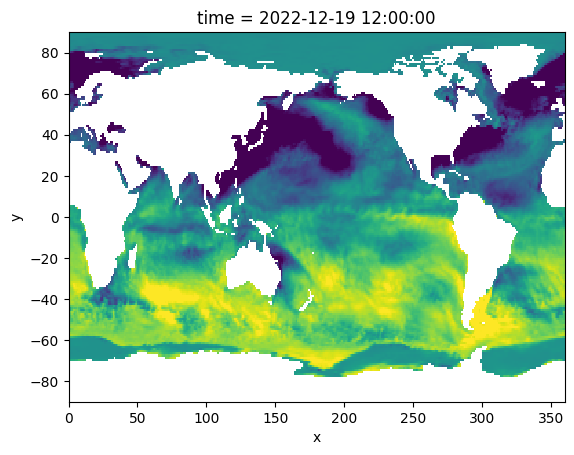

In [42]:
plt.clf()
# Ocean temperature map
# ds_groundtruth.thetao.isel(lev=0).isel(time=-1).plot(vmin=0, vmax=30, cmap='RdBu_r',
#         add_colorbar=False, xticks=[], yticks=[])
# plt.show()

# Atmosphere heatflux map
ds_groundtruth.hfds.isel(time=-1).plot(vmin=-200, vmax=200, add_colorbar=False)
plt.show()


In [73]:
# %matplotlib inline

In [74]:
# ds_groundtruth = ds_input.isel(time=slice(None, 4000))
# with ProgressBar():
#     profile_groundtruth = profile_mean(ds_groundtruth).load()

In [75]:
# # profile_groundtruth.thetao.isel(lev=7).plot()
# # plt.show()
# profile_groundtruth.thetao.isel(lev=7).isel(time=slice(None, 4000)).plot()
# plt.show()

In [76]:
# ds_groundtruth = ds_input.isel(time=slice(3143, 4743))
# with ProgressBar():
#     profile_groundtruth = profile_mean(ds_groundtruth).load()
# profile_groundtruth.thetao.isel(lev=7).isel(time=slice(1000, None)).plot()
# plt.show()

In [ ]:
# ds_prediction_trops = ds_prediction.sel(x=slice(190, 200), y=slice(-5,5))
# ds_groundtruth_trops = ds_groundtruth.sel(x=slice(190, 200), y=slice(-5,5))
# with ProgressBar():
#     profile_prediction = profile_mean(ds_prediction_trops).load()
#     profile_groundtruth = profile_mean(ds_groundtruth_trops).load()
#     profile_stdv_prediction = profile_std(ds_prediction_trops).load()
#     profile_stdv_groundtruth = profile_std(ds_groundtruth_trops).load()
#     stdv_groundtruth = full_std(ds_groundtruth_trops).load()

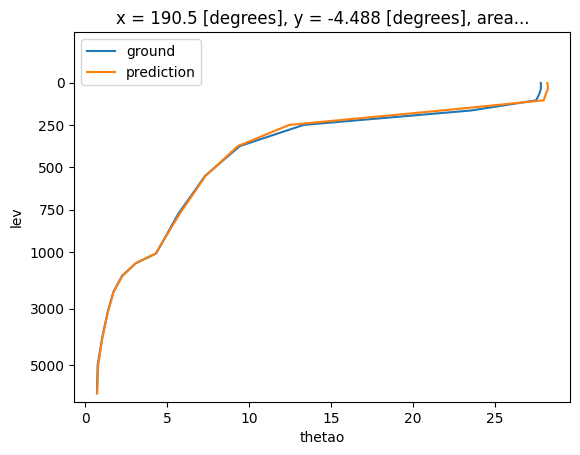

In [ ]:
ds_groundtruth_trops.thetao.isel(x=0,y=0,time=599).plot(y='lev', yincrease=False, label='ground')
ds_prediction_trops.thetao.isel(x=0,y=0,time=599).plot(y='lev', yincrease=False, label='prediction')
ax = plt.gca()
linear_piecewise_scale(1000, 5)
#indicate the point between the different scalings
# ax.axhline(1000, color='0.5', ls='--')
# Rearange the yticks
plt.legend()
ax.set_yticks([0, 250, 500, 750, 1000, 3000, 5000]);
plt.show()

<Figure size 640x480 with 0 Axes>

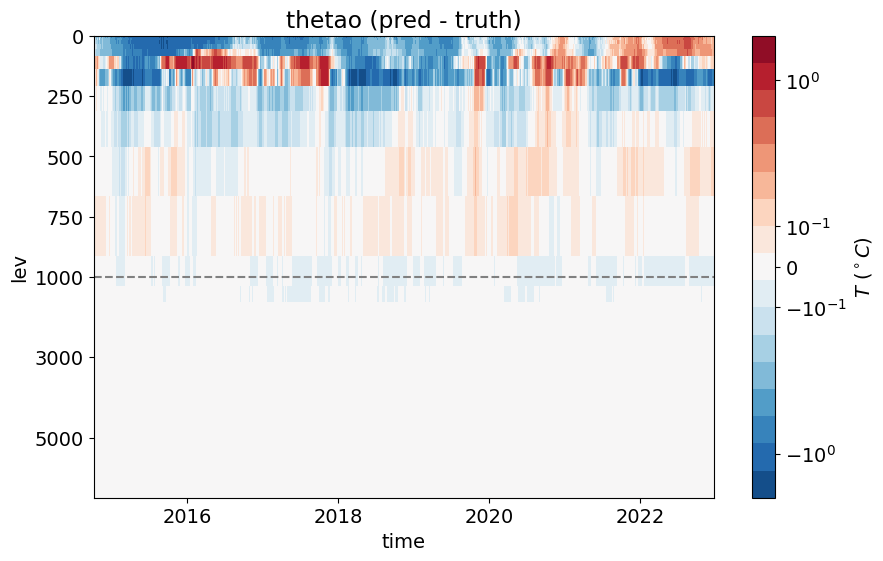

In [ ]:
v = 'thetao'
plot_depth_profile((profile_prediction - profile_groundtruth)[v], title=f"{v} (pred - truth)")